**Step-0: Basic installation to import dataset**

In [ ]:
!pip install opendatasets

**Step-1: Import libraries and download dataset**

In [ ]:
import opendatasets as od
import os
import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For nicer plots
plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.1)

In [ ]:
# Download the dataset from Kaggle using opendatasets
dataset_url = "https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data"

od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: anirbangarai
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data


100%|██████████| 98.4M/98.4M [00:00<00:00, 1.38GB/s]

**Step-2: Load and combine all CSV files**

In [ ]:
# Folder where files are downloaded
data_dir = "./bitcoin-historical-data"

# List all CSV files in that folder
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
print("CSV files found:")
for f in csv_files:
    print("-", os.path.basename(f))

CSV files found:
- btcusd_1-min_data.csv


In [ ]:
# Function to load one CSV and add exchange name
def load_exchange_data(path):
    df = pd.read_csv(path)

    # Add exchange name from filename
    df['exchange'] = os.path.basename(path).replace('.csv', '')

    # Convert UNIX Timestamp to datetime
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')

    # Sort by time
    df = df.sort_values('Timestamp')
    return df

# Load all files and combine into one big DataFrame
dfs = [load_exchange_data(f) for f in csv_files]
data = pd.concat(dfs, ignore_index=True)

print("Shape of combined data:", data.shape)
data.head()

Shape of combined data: (7323517, 7)


,Timestamp,Open,High,Low,Close,Volume,exchange
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.0,btcusd_1-min_data
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.0,btcusd_1-min_data
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.0,btcusd_1-min_data
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.0,btcusd_1-min_data
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.0,btcusd_1-min_data


**Step-3: Data cleaning & make 'daily' data**

In [ ]:
df = data.copy()

# rename Timestamp column to Date for clarity
df.rename(columns={'Timestamp': 'Date'}, inplace=True)

# sort by exchange and Date
df = df.sort_values(['exchange', 'Date'])

# set Date as index
df.set_index('Date', inplace=True)

daily = df['Close'].resample('D').last().to_frame(name='price')

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7323517 entries, 2012-01-01 10:01:00 to 2025-12-04 23:57:00
Data columns (total 6 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Open      float64
 1   High      float64
 2   Low       float64
 3   Close     float64
 4   Volume    float64
 5   exchange  object 
dtypes: float64(5), object(1)
memory usage: 391.1+ MB


**Task-1: Price distribution (not forecasting)**

A. Overall Price Distribution (Histogram)

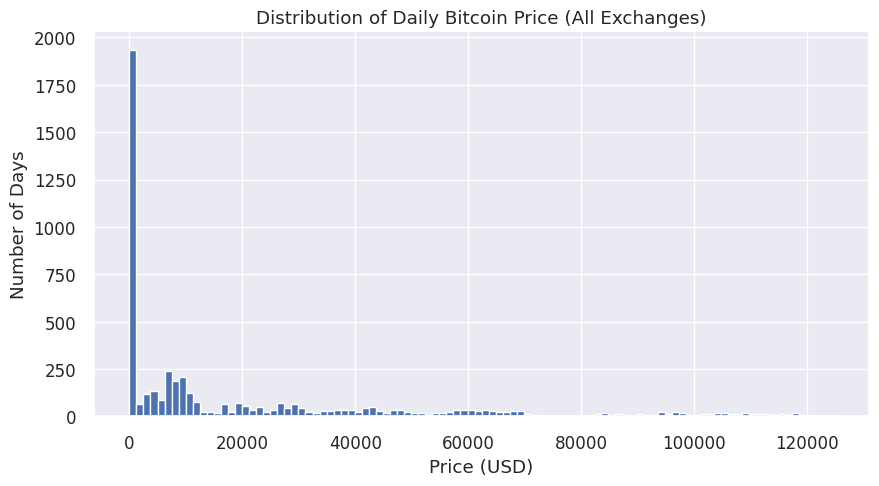

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(daily['price'].dropna(), bins=100)
plt.title("Distribution of Daily Bitcoin Price (All Exchanges)")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Days")
plt.show()

B. Price Distribution by Year (Boxplot)

<Figure size 2000x1200 with 0 Axes>

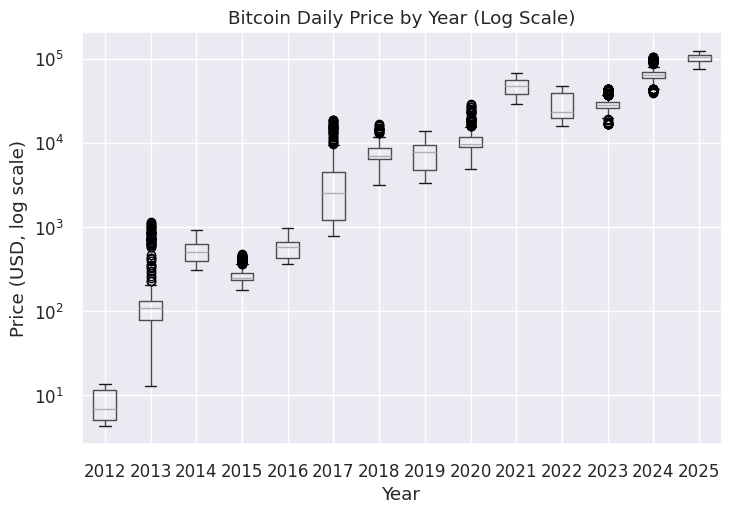

In [ ]:
# Add Year column by extracting from the DataFrame's index
daily['Year'] = daily.index.year

plt.figure(figsize=(20, 12))
daily.boxplot(column='price', by='Year')
plt.yscale('log')  # price grows a lot over time, so log scale helps
plt.title("Bitcoin Daily Price by Year (Log Scale)")
plt.suptitle("")   # remove extra title
plt.xlabel("Year")
plt.ylabel("Price (USD, log scale)")
plt.show()

**Task-2: Volume spikes**

In [ ]:
unique_exchanges = df['exchange'].unique()
print(f"Available exchanges: {unique_exchanges}")

exchange_name = unique_exchanges[0] if len(unique_exchanges) > 0 else "btcusd_1-min_data"
print(f"Using exchange: {exchange_name}")

daily_ex_raw = df[df['exchange'] == exchange_name].copy()

daily_ex = daily_ex_raw.resample('D').agg({
    'Close': 'last',
    'Volume': 'sum'
}).rename(columns={'Close': 'price', 'Volume': 'daily_volume'})

daily_ex['Year'] = daily_ex.index.year

daily_ex.head()

Available exchanges: ['btcusd_1-min_data']
Using exchange: btcusd_1-min_data


,price,daily_volume,Year
Date,,,
2012-01-01,4.84,10.000000,2012
2012-01-02,5.00,10.100000,2012
2012-01-03,5.29,107.085281,2012
2012-01-04,5.57,107.233260,2012
2012-01-05,6.42,70.328742,2012


Volume spikes using mean and STD

In [ ]:
# Calculate mean and std of daily volume
mean_vol = daily_ex['daily_volume'].mean()
std_vol = daily_ex['daily_volume'].std()

# Define a spike: volume > mean + 2 * std
threshold = mean_vol + 2 * std_vol
print("Volume spike threshold:", threshold)

spikes = daily_ex[daily_ex['daily_volume'] > threshold]
spikes.head()

Volume spike threshold: 25368.704899485754


,price,daily_volume,Year
Date,,,
2013-04-11,60.01,38235.671653,2013
2013-04-12,81.50,31876.077807,2013
2013-04-16,65.20,40810.316817,2013
2013-04-17,87.03,30555.080694,2013
2013-04-19,117.00,30985.778189,2013


Plot volume and Highlight spikes

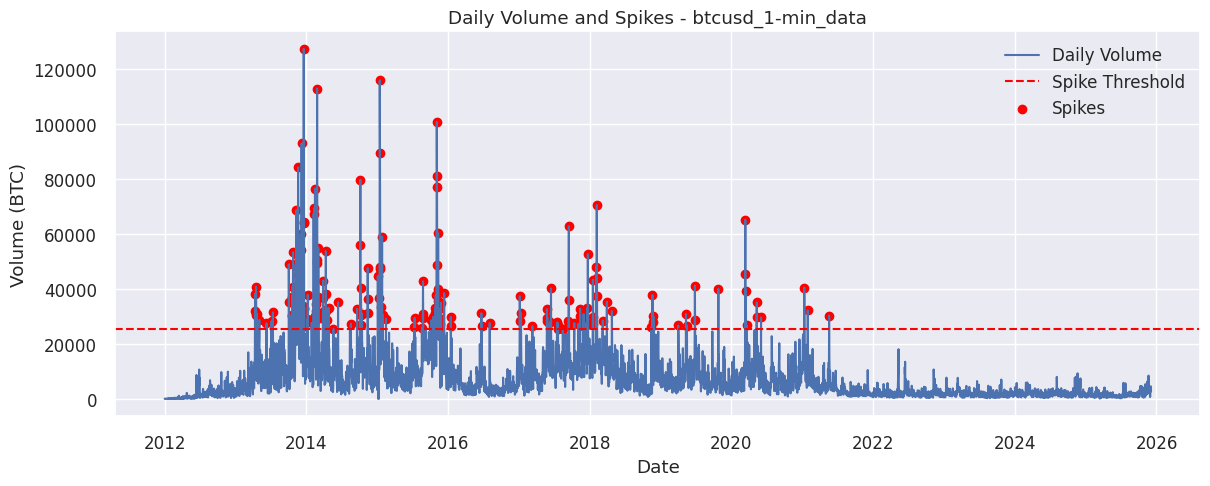

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(daily_ex.index, daily_ex['daily_volume'], label='Daily Volume')
plt.axhline(threshold, color='red', linestyle='--', label='Spike Threshold')

# Mark spike days with red dots
plt.scatter(spikes.index, spikes['daily_volume'], color='red', label='Spikes')

plt.title(f"Daily Volume and Spikes - {exchange_name}")
plt.xlabel("Date")
plt.ylabel("Volume (BTC)")
plt.legend()
plt.show()

**Task-3: Coin-wise comparison**

A. Average Price per Exchange

exchange
btcusd_1-min_data    21319.732843
Name: Close, dtype: float64


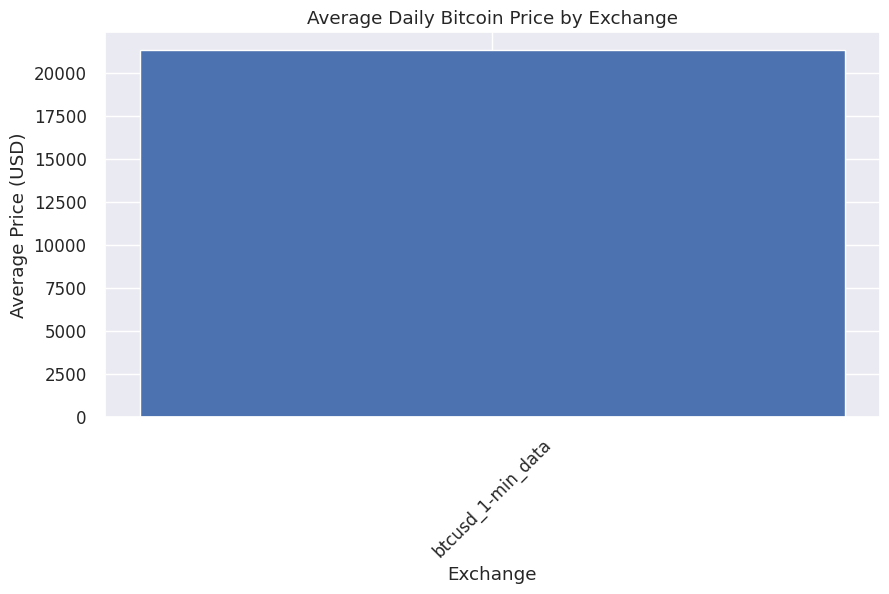

In [ ]:
# the average daily price for each exchange.

# Group the minute-level DataFrame 'df' by 'exchange',
# then for each exchange, resample the 'Close' price to daily (taking the last price),
# and finally, calculate the mean of these daily prices for each exchange.
avg_price_by_exchange = df.groupby('exchange')['Close'].resample('D').last().groupby('exchange').mean().sort_values()

print(avg_price_by_exchange)

plt.figure(figsize=(10, 5))
plt.bar(avg_price_by_exchange.index, avg_price_by_exchange.values)
plt.xticks(rotation=45)
plt.title("Average Daily Bitcoin Price by Exchange")
plt.xlabel("Exchange")
plt.ylabel("Average Price (USD)")
plt.show()

B. Plot Price Over Time for a Few Exchanges

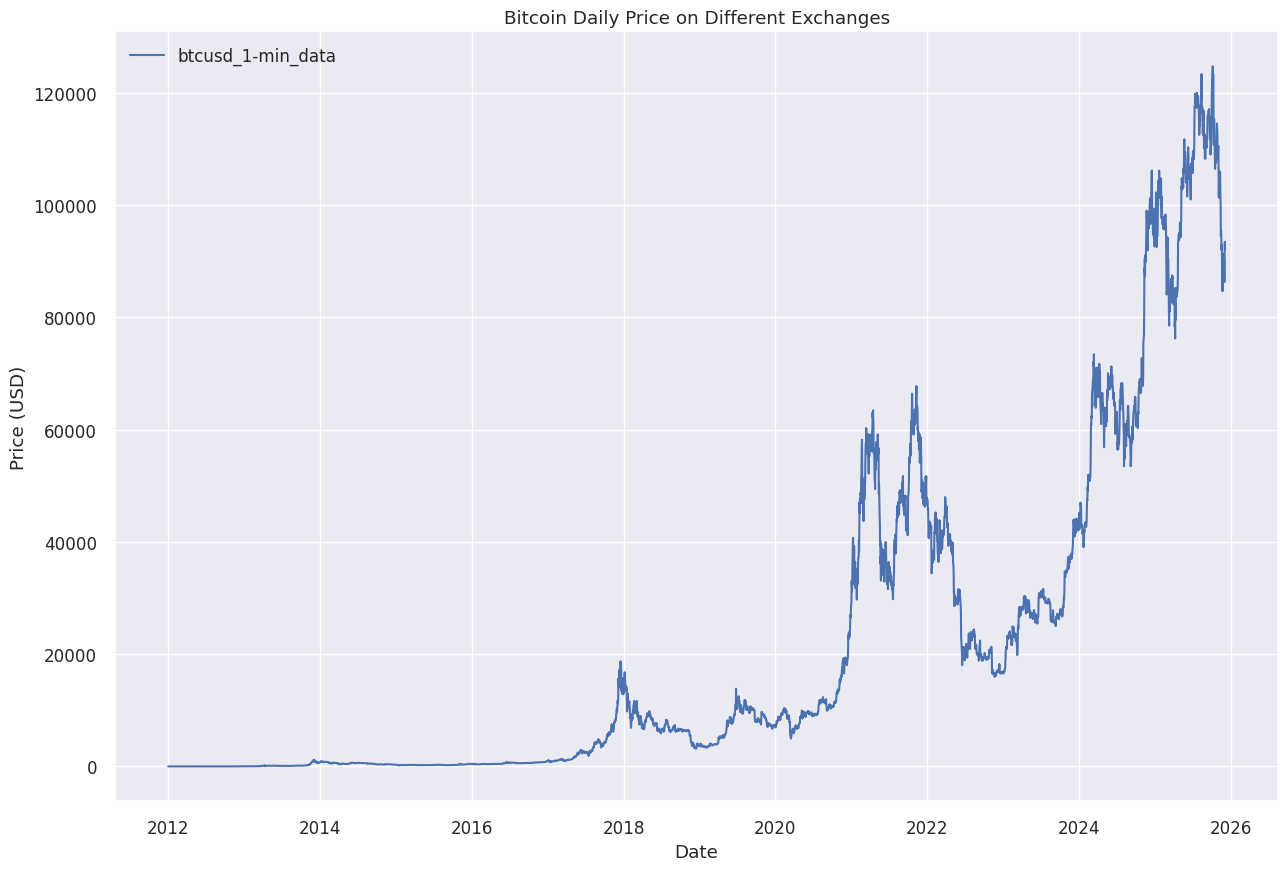

In [ ]:
# Create a DataFrame with daily prices for each exchange
# The original 'df' DataFrame contains the 'exchange' column and minute-level data.
# We group by exchange, then resample to daily, taking the last 'Close' price.
daily_prices_by_exchange = df.groupby('exchange')['Close'].resample('D').last().to_frame(name='price')

# Reset the index to make 'exchange' and 'Date' regular columns, then pivot
price_pivot = daily_prices_by_exchange.reset_index().pivot_table(index='Date',
                                                  columns='exchange',
                                                  values='price')

# Pick first 3 exchanges (or fewer if less than 3 exist)
selected_exchanges = price_pivot.columns[:3]

plt.figure(figsize=(15, 10))

for ex in selected_exchanges:
    plt.plot(price_pivot.index, price_pivot[ex], label=ex)

plt.title("Bitcoin Daily Price on Different Exchanges")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

**Task-4: Identify correlation in crypto behaviour**

A. Compute Daily Returns per Exchange

In [ ]:
# Daily percentage returns
returns = price_pivot.pct_change().dropna()
returns.head()

exchange,btcusd_1-min_data
Date,
2012-01-02,0.033058
2012-01-03,0.058000
2012-01-04,0.052930
2012-01-05,0.152603
2012-01-06,-0.003115


B. Correlation Matrix

In [ ]:
corr_matrix = returns.corr()
corr_matrix

exchange,btcusd_1-min_data
exchange,
btcusd_1-min_data,1.0


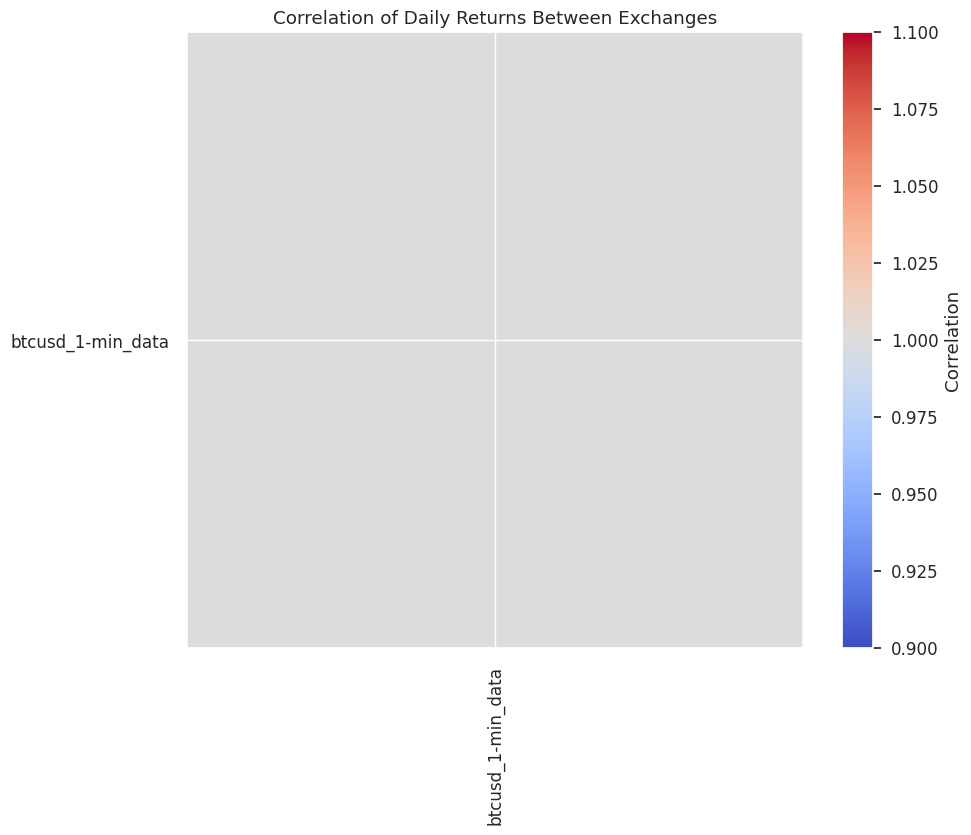

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation of Daily Returns Between Exchanges")
plt.show()